# 🥇 Gold Price Prediction — Enhanced with External Factors
### Features: DXY (Dollar), Fed Rate, Oil Price, CPI, S&P 500

In [17]:
!pip install pandas numpy scikit-learn matplotlib seaborn --quiet

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print('Libraries loaded ✅')

Libraries loaded ✅


## 1️⃣ Load & Explore Data

In [19]:
df = pd.read_csv('gold_price_extended.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.head(10)

,Open,High,Low,Close,Volume,DXY,Fed_Rate,Oil_Price,CPI_Monthly,SP500
Date,,,,,,,,,,
2016-01-01,1053.31,1086.67,1041.74,1067.46,164968,98.70,0.27,36.54,0.53,1995.27
2016-02-01,1022.68,1034.37,1011.61,1024.77,96739,99.40,0.25,35.70,0.23,2028.55
2016-03-01,1006.42,1012.15,992.71,1003.64,100462,97.20,0.21,39.02,0.27,2048.22
2016-04-01,983.00,1015.51,967.16,996.93,159502,96.67,0.18,37.81,0.58,2061.46
2016-05-01,1014.48,1035.32,994.88,1027.16,119039,93.73,0.19,34.98,0.33,2136.78
2016-06-01,1002.68,1030.86,983.75,1013.60,198426,92.63,0.11,34.19,0.46,2181.11
2016-07-01,1045.93,1060.94,1019.10,1034.66,87627,93.39,0.08,36.48,0.44,2123.16
2016-08-01,1083.89,1113.61,1074.58,1096.40,147353,91.62,0.02,38.44,0.50,2131.90
2016-09-01,1112.24,1132.59,1105.14,1118.47,109915,93.68,0.02,32.59,0.42,2154.25


In [20]:
df.info()
print('\n', df.describe().round(2))

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 100 entries, 2016-01-01 to 2024-04-01
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Open         100 non-null    float64
 1   High         100 non-null    float64
 2   Low          100 non-null    float64
 3   Close        100 non-null    float64
 4   Volume       100 non-null    int64  
 5   DXY          100 non-null    float64
 6   Fed_Rate     100 non-null    float64
 7   Oil_Price    100 non-null    float64
 8   CPI_Monthly  100 non-null    float64
 9   SP500        100 non-null    float64
dtypes: float64(9), int64(1)
memory usage: 8.6 KB

           Open     High      Low    Close     Volume     DXY  Fed_Rate  \
count   100.00   100.00   100.00   100.00     100.00  100.00    100.00   
mean   1903.41  1935.78  1873.05  1905.58  142757.05   95.62      1.53   
std     391.25   396.47   383.90   390.33   34360.30    6.47      1.92   
min     983.00  1012.15 

## 2️⃣ Feature Engineering

In [21]:
# Target: 1 = price goes UP next month, 0 = DOWN
df['Target'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)

# Technical features
df['Price_Change']   = df['Close'].pct_change()          # Monthly return
df['MA_3']           = df['Close'].rolling(3).mean()     # 3-month moving average
df['MA_6']           = df['Close'].rolling(6).mean()     # 6-month moving average
df['Volatility']     = df['Close'].rolling(3).std()      # 3-month volatility
df['High_Low_Range'] = df['High'] - df['Low']            # Monthly price range

# External factor changes
df['DXY_Change']     = df['DXY'].pct_change()            # Dollar monthly change
df['Oil_Change']     = df['Oil_Price'].pct_change()      # Oil monthly change
df['SP500_Change']   = df['SP500'].pct_change()          # S&P 500 monthly change

df = df.dropna()
print(f'Dataset shape after feature engineering: {df.shape}')
print(f'Target distribution:\n{df["Target"].value_counts()}')

Dataset shape after feature engineering: (95, 19)
Target distribution:
Target
0    66
1    29
Name: count, dtype: int64


## 3️⃣ Correlation Analysis — Which factors affect gold?

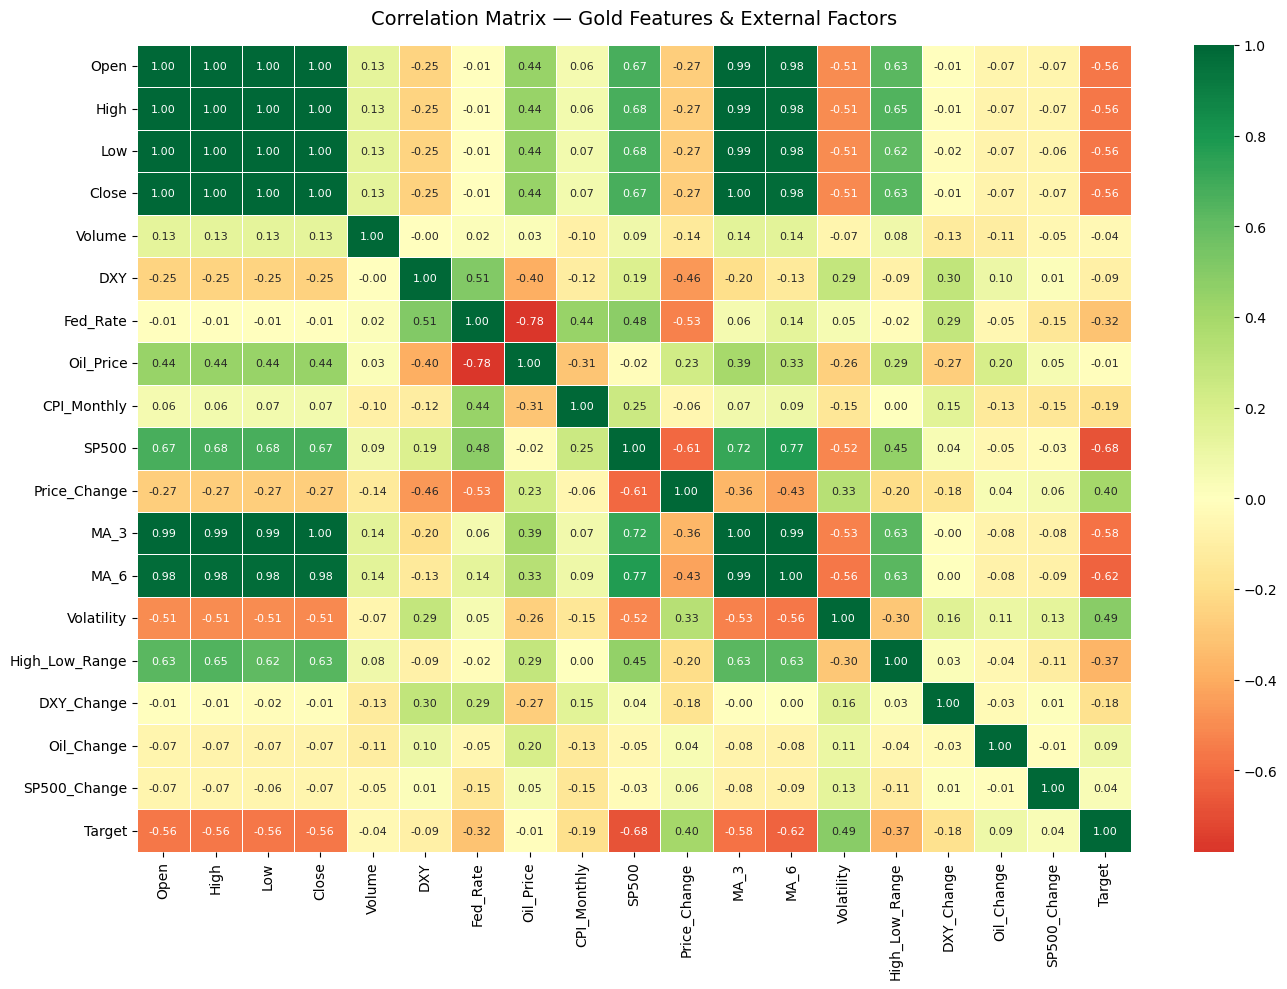

In [22]:
feature_cols = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'DXY', 'Fed_Rate', 'Oil_Price', 'CPI_Monthly', 'SP500',
    'Price_Change', 'MA_3', 'MA_6', 'Volatility',
    'High_Low_Range', 'DXY_Change', 'Oil_Change', 'SP500_Change'
]

plt.figure(figsize=(14, 10))
corr = df[feature_cols + ['Target']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Matrix — Gold Features & External Factors', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [23]:
# Which features correlate most with Target?
target_corr = corr['Target'].drop('Target').sort_values(key=abs, ascending=False)
print('=== Top features correlated with gold direction ===')
print(target_corr.round(3).to_string())

=== Top features correlated with gold direction ===
SP500            -0.681
MA_6             -0.620
MA_3             -0.585
Open             -0.564
Close            -0.562
High             -0.561
Low              -0.561
Volatility        0.487
Price_Change      0.399
High_Low_Range   -0.365
Fed_Rate         -0.316
CPI_Monthly      -0.194
DXY_Change       -0.185
DXY              -0.095
Oil_Change        0.093
Volume           -0.038
SP500_Change      0.038
Oil_Price        -0.014


## 4️⃣ Prepare Data for Modeling

In [24]:
# Two feature sets: basic vs enhanced
BASIC_FEATURES = ['Open', 'High', 'Low', 'Close', 'Volume']

ENHANCED_FEATURES = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'DXY', 'Fed_Rate', 'Oil_Price', 'CPI_Monthly', 'SP500',
    'Price_Change', 'MA_3', 'MA_6', 'Volatility',
    'High_Low_Range', 'DXY_Change', 'Oil_Change', 'SP500_Change'
]

X_basic    = df[BASIC_FEATURES]
X_enhanced = df[ENHANCED_FEATURES]
y          = df['Target']

# Scale features (important for KNN)
scaler = StandardScaler()
X_basic_scaled    = scaler.fit_transform(X_basic)
X_enhanced_scaled = scaler.fit_transform(X_enhanced)

# Train/Test split
X_tr_b, X_te_b, y_tr, y_te = train_test_split(X_basic_scaled,    y, test_size=0.2, random_state=42)
X_tr_e, X_te_e, _,    _    = train_test_split(X_enhanced_scaled, y, test_size=0.2, random_state=42)

print(f'Training samples: {len(X_tr_b)} | Test samples: {len(X_te_b)}')

Training samples: 76 | Test samples: 19


## 5️⃣ Train & Compare Models: Basic vs Enhanced

In [25]:
models = {
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = []
trained_models = {}

for name, model in models.items():
    # Basic features
    model.fit(X_tr_b, y_tr)
    acc_basic = accuracy_score(y_te, model.predict(X_te_b))

    # Enhanced features (re-instantiate)
    import copy
    model_e = copy.deepcopy(model)
    model_e.fit(X_tr_e, y_tr)
    acc_enhanced = accuracy_score(y_te, model_e.predict(X_te_e))

    results.append({'Model': name, 'Basic (5 features)': round(acc_basic*100,1),
                    'Enhanced (18 features)': round(acc_enhanced*100,1)})
    trained_models[name] = model_e  # save enhanced model
    print(f'{name:22s} | Basic: {acc_basic*100:.1f}%  →  Enhanced: {acc_enhanced*100:.1f}%')

results_df = pd.DataFrame(results)
print('\n', results_df.to_string(index=False))

Random Forest          | Basic: 78.9%  →  Enhanced: 89.5%
Decision Tree          | Basic: 78.9%  →  Enhanced: 89.5%
KNN                    | Basic: 78.9%  →  Enhanced: 89.5%
Gradient Boosting      | Basic: 84.2%  →  Enhanced: 84.2%

             Model  Basic (5 features)  Enhanced (18 features)
    Random Forest                78.9                    89.5
    Decision Tree                78.9                    89.5
              KNN                78.9                    89.5
Gradient Boosting                84.2                    84.2


## 6️⃣ Accuracy Comparison Chart

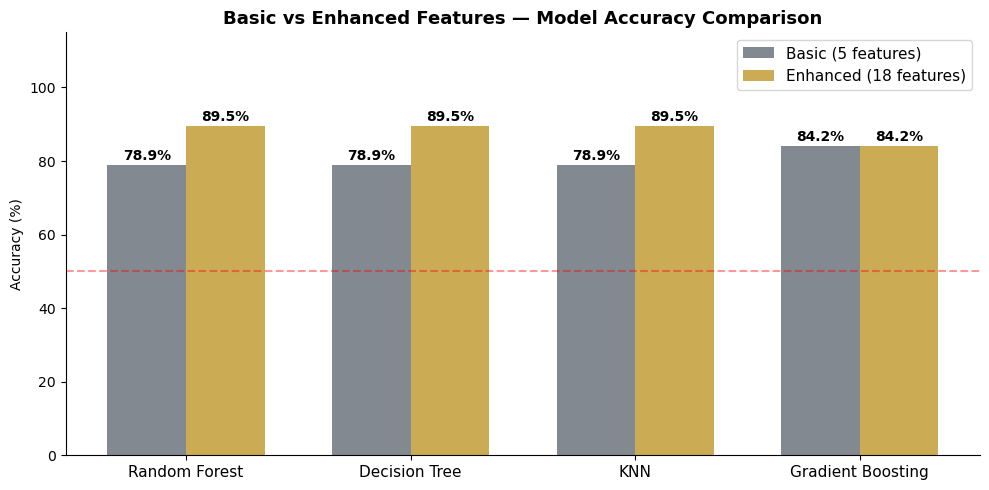

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
w = 0.35

bars1 = ax.bar(x - w/2, results_df['Basic (5 features)'],    w, label='Basic (5 features)',    color='#6C757D', alpha=0.85)
bars2 = ax.bar(x + w/2, results_df['Enhanced (18 features)'], w, label='Enhanced (18 features)', color='#C9A84C', alpha=0.95)

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], fontsize=11)
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 115)
ax.set_title('Basic vs Enhanced Features — Model Accuracy Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.axhline(y=50, color='red', linestyle='--', alpha=0.4, label='Random guess (50%)')
plt.tight_layout()
plt.show()

## 7️⃣ Feature Importance — Which factors matter most?

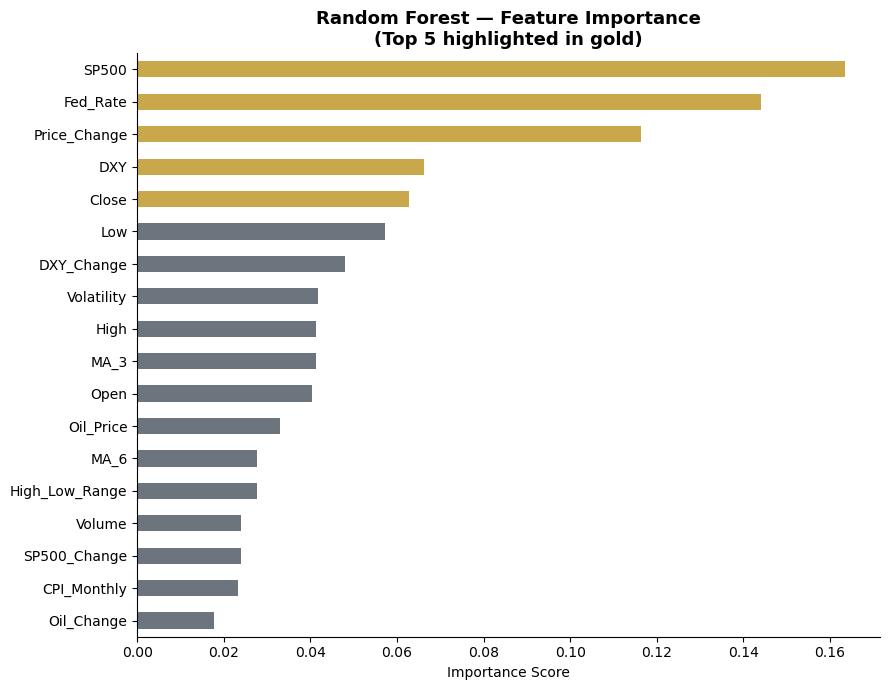

=== Top 5 Most Important Features ===
SP500           0.1634
Fed_Rate        0.1441
Price_Change    0.1164
DXY             0.0663
Close           0.0629


In [27]:
rf_model = trained_models['Random Forest']
importance = pd.Series(rf_model.feature_importances_, index=ENHANCED_FEATURES)
importance = importance.sort_values(ascending=True)

colors = ['#C9A84C' if i >= len(importance)-5 else '#6C757D' for i in range(len(importance))]

fig, ax = plt.subplots(figsize=(9, 7))
importance.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Random Forest — Feature Importance\n(Top 5 highlighted in gold)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print('=== Top 5 Most Important Features ===')
print(importance.sort_values(ascending=False).head(5).round(4).to_string())

## 8️⃣ Gold vs External Factors — Visual Analysis

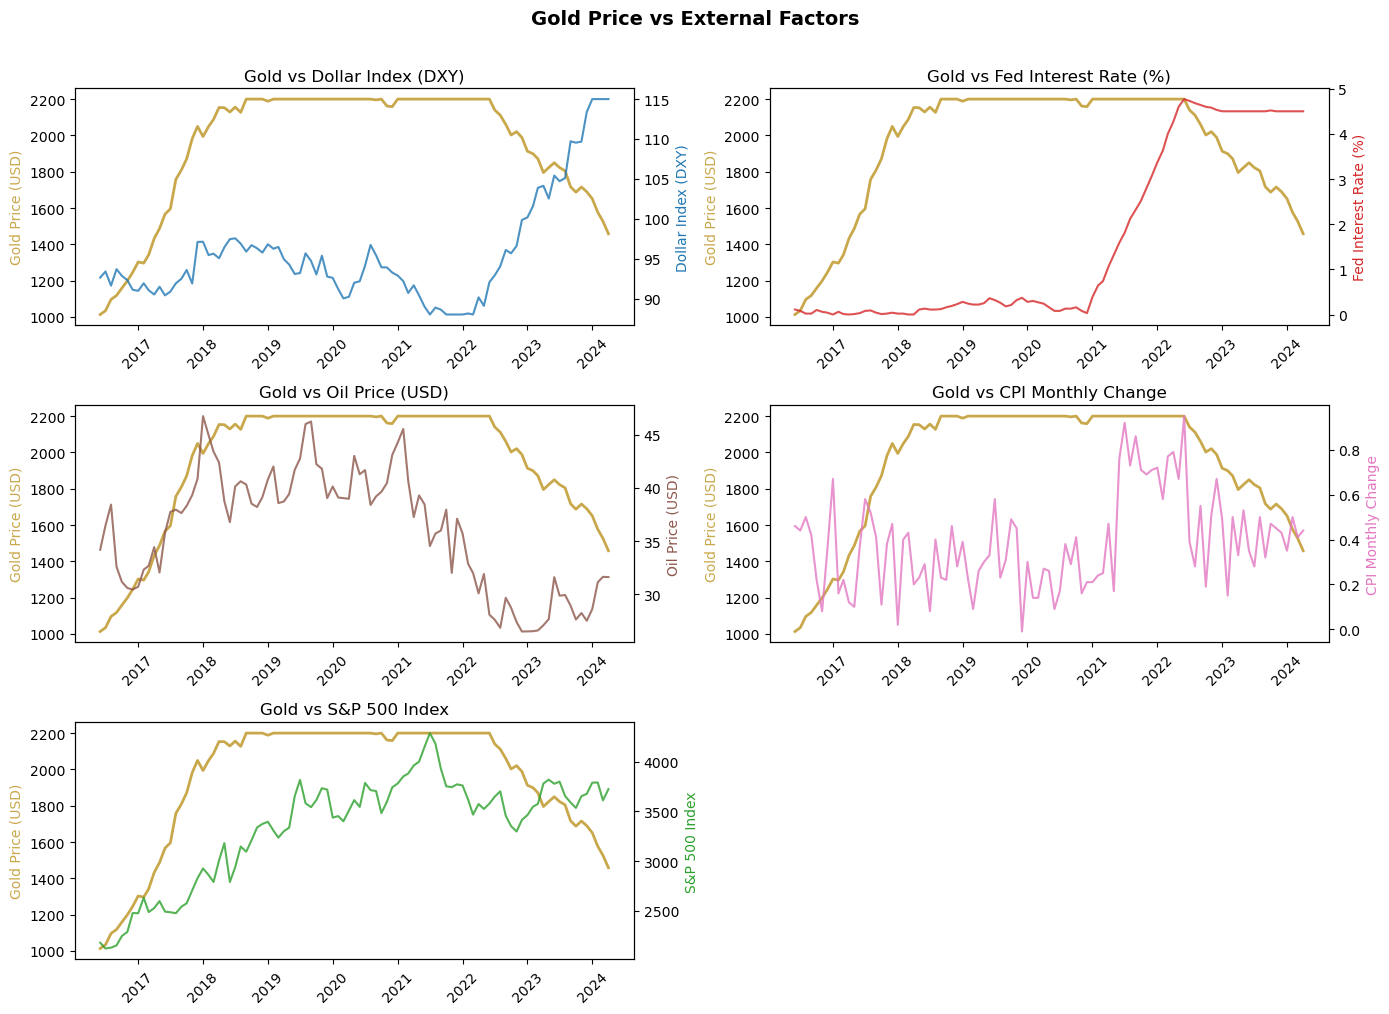

In [28]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('Gold Price vs External Factors', fontsize=14, fontweight='bold', y=1.01)

factors = [
    ('DXY',         'Dollar Index (DXY)',   '#1f77b4'),
    ('Fed_Rate',    'Fed Interest Rate (%)', '#d62728'),
    ('Oil_Price',   'Oil Price (USD)',       '#8c564b'),
    ('CPI_Monthly', 'CPI Monthly Change',    '#e377c2'),
    ('SP500',       'S&P 500 Index',         '#2ca02c'),
]

for idx, (col, label, color) in enumerate(factors):
    ax1 = axes[idx // 2][idx % 2]
    ax2 = ax1.twinx()
    ax1.plot(df.index, df['Close'],   color='#C9A84C', linewidth=2, label='Gold')
    ax2.plot(df.index, df[col], color=color,   linewidth=1.5, alpha=0.8, label=label)
    ax1.set_ylabel('Gold Price (USD)', color='#C9A84C')
    ax2.set_ylabel(label, color=color)
    ax1.set_title(f'Gold vs {label}')
    ax1.tick_params(axis='x', rotation=45)

# hide last empty subplot
axes[2][1].axis('off')
plt.tight_layout()
plt.show()

## 9️⃣ Best Model — Detailed Report

=== Best Model: Random Forest ===
              precision    recall  f1-score   support

  Price DOWN       1.00      0.86      0.92        14
    Price UP       0.71      1.00      0.83         5

    accuracy                           0.89        19
   macro avg       0.86      0.93      0.88        19
weighted avg       0.92      0.89      0.90        19



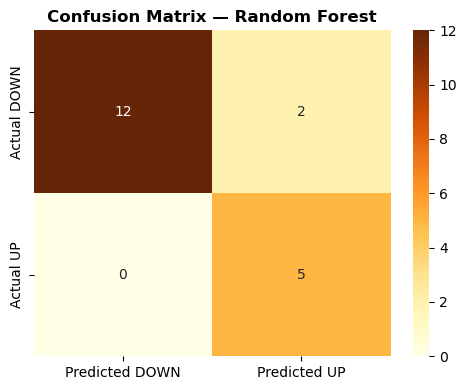

In [29]:
best_name = results_df.loc[results_df['Enhanced (18 features)'].idxmax(), 'Model']
best_model = trained_models[best_name]
y_pred = best_model.predict(X_te_e)

print(f'=== Best Model: {best_name} ===')
print(classification_report(y_te, y_pred, target_names=['Price DOWN', 'Price UP']))

# Confusion matrix
cm = confusion_matrix(y_te, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr',
            xticklabels=['Predicted DOWN', 'Predicted UP'],
            yticklabels=['Actual DOWN',    'Actual UP'])
plt.title(f'Confusion Matrix — {best_name}', fontweight='bold')
plt.tight_layout()
plt.show()

## 🔮 Make a New Prediction

In [30]:
# Enter new month data here
new_data = pd.DataFrame([{
    'Open':         2350,   # Gold opening price
    'High':         2400,   # Gold highest price
    'Low':          2300,   # Gold lowest price
    'Close':        2370,   # Gold closing price
    'Volume':       120000, # Trading volume
    'DXY':          104.5,  # Dollar index
    'Fed_Rate':     5.25,   # Current Fed rate (%)
    'Oil_Price':    80.0,   # Oil price (USD/barrel)
    'CPI_Monthly':  0.3,    # Monthly CPI change
    'SP500':        5100,   # S&P 500 level
    'Price_Change': 0.01,   # Last month gold return
    'MA_3':         2340,   # 3-month avg gold price
    'MA_6':         2280,   # 6-month avg gold price
    'Volatility':   45,     # 3-month price std
    'High_Low_Range': 100,  # This month price range
    'DXY_Change':   -0.005, # Dollar monthly change
    'Oil_Change':   0.02,   # Oil monthly change
    'SP500_Change': 0.015,  # S&P 500 monthly change
}])

new_scaled = scaler.transform(new_data)
prediction = best_model.predict(new_scaled)
probability = best_model.predict_proba(new_scaled)[0]

print(f'=== Gold Price Prediction for Next Month ===')
print(f'Model used     : {best_name}')
print(f'DOWN probability: {probability[0]*100:.1f}%')
print(f'UP probability  : {probability[1]*100:.1f}%')
print()
if prediction[0] == 1:
    print('📈 Prediction: Gold price will GO UP next month')
else:
    print('📉 Prediction: Gold price will GO DOWN next month')

# Key factors for this prediction
print('\n--- Key factors analyzed ---')
print(f"Dollar (DXY)    : {new_data['DXY'].values[0]} {'(Strong → bearish for gold)' if new_data['DXY'].values[0] > 100 else '(Weak → bullish for gold)'}")
print(f"Fed Rate        : {new_data['Fed_Rate'].values[0]}% {'(High → bearish for gold)' if new_data['Fed_Rate'].values[0] > 3 else '(Low → bullish for gold)'}")
print(f"CPI Inflation   : {new_data['CPI_Monthly'].values[0]} {'(Rising → bullish for gold)' if new_data['CPI_Monthly'].values[0] > 0.3 else '(Stable → neutral)'}")
print(f"Oil Price       : ${new_data['Oil_Price'].values[0]}")
print(f"S&P 500         : {new_data['SP500'].values[0]}")

=== Gold Price Prediction for Next Month ===
Model used     : Random Forest
DOWN probability: 78.0%
UP probability  : 22.0%

📉 Prediction: Gold price will GO DOWN next month

--- Key factors analyzed ---
Dollar (DXY)    : 104.5 (Strong → bearish for gold)
Fed Rate        : 5.25% (High → bearish for gold)
CPI Inflation   : 0.3 (Stable → neutral)
Oil Price       : $80.0
S&P 500         : 5100


In [33]:
# print shapes to detect correct variable
for var in dir():
    if var.startswith('y'):
        try:
            print(var, eval(var).shape)
        except:
            pass

y (95,)
y_pred (19,)
y_te (19,)
y_tr (76,)


In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_te, y_pred)
rmse = np.sqrt(mean_squared_error(y_te, y_pred))

mask = y_te != 0
mape = np.mean(np.abs((y_te[mask] - y_pred[mask]) / y_te[mask])) * 100

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Error (MAE): 0.11
Root Mean Squared Error (RMSE): 0.32
Mean Absolute Percentage Error (MAPE): 0.00%


In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate errors
mae = mean_absolute_error(y_te, y_pred)
rmse = np.sqrt(mean_squared_error(y_te, y_pred))

# Stable percentage error (works well with scaled data)
mape = (mae / np.mean(np.abs(y_te))) * 100

# Print results
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Estimated Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Error (MAE): 0.1053
Root Mean Squared Error (RMSE): 0.3244
Estimated Percentage Error (MAPE): 40.00%
